# Notebook 08 — XGBoost Regression
**Project:** Climate-Driven Solar Energy Analytics  
**Author:** BMSCE MCA Research Project  
**Dataset:** NASA POWER · 15 Indian Cities · 2019–2024  

---

### Position in the pipeline

```
01_data_collection  →  02_data_understanding  →  03_seasonal_analysis
→  04_city_comparison  →  05_vif_outlier_analysis  →  06_feature_engineering
→  07_regression_models  →  [08_xgboost]  ← you are here
→  09_shap  →  10_recommender
```

### What this notebook does

This notebook trains an **XGBoost Gradient Boosting Regressor** for daily solar irradiance
prediction and benchmarks it against the three baseline models from Notebook 07:

| NB | Model | Type |
|----|-------|------|
| 07 | Linear Regression | Linear baseline |
| 07 | Ridge Regression | Regularised linear |
| 07 | Random Forest | Nonlinear ensemble |
| **08** | **XGBoost** | **Gradient boosted trees** |

### Research question

> Does XGBoost provide a meaningful improvement over the baseline models for predicting
> `ALLSKY_SFC_SW_DWN` across 15 Indian cities — and is it accurate enough for
> real-world solar energy planning decisions?

### Critical constraints carried forward from NB05 & NB06

| Constraint | Detail |
|-----------|--------|
| **No T2M_MIN** | VIF infinite in Set B — removed in NB05, asserted here |
| **No random split / no shuffle** | Temporal split: 2019–2022 train · 2023–2024 test |
| **Features from config file** | `nb06_preprocessing_config.json` — never hardcoded |
| **TimeSeriesSplit for CV** | Weather is ordered time-series; KFold would cause leakage |
| **Scaler from NB06** | `scaler_extended.pkl` — fit on train only, applied here |

### Outputs for NB09 (SHAP Explainability)

| File | Used by NB09 |
|------|-------------|
| `outputs/xgboost_model.pkl` | Primary model for SHAP TreeExplainer |
| `outputs/nb08_feature_importance.csv` | Cross-check with SHAP values |
| `outputs/nb08_best_model.pkl` | Best model overall (NB07 + NB08 comparison) |


## Cell 1 — Imports & Project Constants

In [1]:
import os
import json
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import joblib

from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ── Matplotlib style (consistent with NB03–NB07) ─────────────────────────
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   '#f8f9fa',
    'axes.grid':        True,
    'grid.alpha':       0.4,
    'font.family':      'sans-serif',
    'axes.titlesize':   13,
    'axes.labelsize':   11,
    'xtick.labelsize':  9,
    'ytick.labelsize':  9,
})

# ── Project constants ─────────────────────────────────────────────────────
OUT_DIR      = '../outputs'
RANDOM_STATE = 42

os.makedirs(OUT_DIR, exist_ok=True)

# ── Model colour palette (NB07 colours preserved; XGBoost gets orange) ───
COLOURS = {
    'Linear Regression': '#2563eb',
    'Ridge Regression':  '#059669',
    'Random Forest':     '#dc2626',
    'XGBoost':           '#ea580c',
}

print('✓ Imports complete')
print(f'  random_state  = {RANDOM_STATE}')
print(f'  Output dir    = {OUT_DIR}')


✓ Imports complete
  random_state  = 42
  Output dir    = ../outputs


### 4g. Lag Features & Rolling Mean

**Why before the split:** Lag features use `groupby('city').shift()` on the full dataset so the boundary row (first day of the test set) can correctly look back into train-period history. Creating lags after splitting would produce NaN at the boundary and lose that cross-boundary signal.

**City-wise groupby:** Essential — without it, the last day of city A's data would become the "previous day" for city B's first row.

| Feature | Formula | Physical meaning |
|---------|---------|------------------|
| `GHI_LAG1` | GHI shifted 1 day (city-wise) | Yesterday's radiation — weather persistence |
| `RH2M_LAG1` | RH2M shifted 1 day (city-wise) | Yesterday's humidity — moisture memory |
| `CLOUD_LAG1` | CLOUD_AMT shifted 1 day (city-wise) | Cloud system persistence |
| `GHI_7DAY_MEAN` | 7-day rolling mean GHI (city-wise) | Medium-term weather pattern smoothing |

## Cell 2 — Load NB06 Preprocessing Configuration

Feature names are loaded exclusively from `nb06_preprocessing_config.json`.  
**No feature names are hardcoded anywhere in this notebook.**


In [2]:
# ── Load NB06 preprocessing config ───────────────────────────────────────
config_path = os.path.join(OUT_DIR, 'nb06_preprocessing_config.json')

with open(config_path, 'r') as f:
    config = json.load(f)

TARGET            = config['target']
FEATURES_CORE     = config['features_core']
FEATURES_EXTENDED = config['features_extended']
TRAIN_YEARS       = config['split']['train_years']
TEST_YEARS        = config['split']['test_years']

print('Configuration loaded from NB06:')
print(f'  Target variable    : {TARGET}')
print(f'  Core features      : {len(FEATURES_CORE)}  → {FEATURES_CORE}')
print(f'  Extended features  : {len(FEATURES_EXTENDED)} total')
print(f'  Train years        : {TRAIN_YEARS}')
print(f'  Test years         : {TEST_YEARS}')
print()
print('Full FEATURES_EXTENDED list:')
for i, f in enumerate(FEATURES_EXTENDED, 1):
    print(f'  {i:02d}. {f}')


Configuration loaded from NB06:
  Target variable    : ALLSKY_SFC_SW_DWN
  Core features      : 8  → ['T2M_MAX', 'TEMP_RANGE', 'RH2M', 'PS', 'WS10M', 'CLOUD_AMT', 'log1p_PREC', 'WIND_CLOUD']
  Extended features  : 31 total
  Train years        : [2019, 2020, 2021, 2022]
  Test years         : [2023, 2024]

Full FEATURES_EXTENDED list:
  01. T2M_MAX
  02. TEMP_RANGE
  03. RH2M
  04. PS
  05. WS10M
  06. CLOUD_AMT
  07. log1p_PREC
  08. WIND_CLOUD
  09. MONTH_SIN
  10. MONTH_COS
  11. IS_MONSOON
  12. DAY_OF_YEAR
  13. GHI_LAG1
  14. RH2M_LAG1
  15. CLOUD_LAG1
  16. GHI_7DAY_MEAN
  17. CITY_Ahmedabad
  18. CITY_Bengaluru
  19. CITY_Bhopal
  20. CITY_Bhubaneswar
  21. CITY_Chandigarh
  22. CITY_Chennai
  23. CITY_Delhi
  24. CITY_Guwahati
  25. CITY_Hyderabad
  26. CITY_Jaipur
  27. CITY_Kochi
  28. CITY_Kolkata
  29. CITY_Mangalore
  30. CITY_Mumbai
  31. CITY_Pune


## Cell 3 — Load Train & Test Sets

Loads the preprocessed outputs from NB06. The temporal split (2019–2022 / 2023–2024)
is already embedded in these files — **no re-splitting is performed here**.


In [3]:
# ── Load preprocessed datasets produced by NB06 ──────────────────────────
train_df = pd.read_csv(os.path.join(OUT_DIR, 'train_preprocessed.csv'), parse_dates=['date'])
test_df  = pd.read_csv(os.path.join(OUT_DIR, 'test_preprocessed.csv'),  parse_dates=['date'])

print(f'Train set : {train_df.shape}   | Years: {TRAIN_YEARS}')
print(f'Test  set : {test_df.shape}    | Years: {TEST_YEARS}')
print()

# ── Temporal integrity check ──────────────────────────────────────────────
assert train_df['date'].max() < test_df['date'].min(), 'FATAL: Temporal overlap!'
print(f'Train period : {train_df["date"].min().date()} → {train_df["date"].max().date()}')
print(f'Test  period : {test_df["date"].min().date()} → {test_df["date"].max().date()}')
print('✓ No temporal overlap confirmed')
print()

# ── T2M_MIN must NOT be present (NB05 VIF decision) ──────────────────────
assert 'T2M_MIN' not in train_df.columns,    'FATAL: T2M_MIN found in train_df!'
assert 'T2M_MIN' not in FEATURES_EXTENDED,   'FATAL: T2M_MIN in FEATURES_EXTENDED!'
print('✓ T2M_MIN absent — NB05 VIF decision preserved')

# ── All features must be present ─────────────────────────────────────────
missing = [f for f in FEATURES_EXTENDED if f not in train_df.columns]
assert len(missing) == 0, f'Missing features: {missing}'
print(f'✓ All {len(FEATURES_EXTENDED)} features confirmed in train_df')
print()

# ── Target summary ────────────────────────────────────────────────────────
print(f'Target — {TARGET}:')
print(f'  Train  mean={train_df[TARGET].mean():.3f}  std={train_df[TARGET].std():.3f}  '
      f'min={train_df[TARGET].min():.3f}  max={train_df[TARGET].max():.3f}')
print(f'  Test   mean={test_df[TARGET].mean():.3f}  std={test_df[TARGET].std():.3f}  '
      f'min={test_df[TARGET].min():.3f}  max={test_df[TARGET].max():.3f}')


Train set : (21900, 38)   | Years: [2019, 2020, 2021, 2022]
Test  set : (10965, 38)    | Years: [2023, 2024]

Train period : 2019-01-02 → 2022-12-31
Test  period : 2023-01-01 → 2024-12-31
✓ No temporal overlap confirmed

✓ T2M_MIN absent — NB05 VIF decision preserved
✓ All 31 features confirmed in train_df

Target — ALLSKY_SFC_SW_DWN:
  Train  mean=4.966  std=1.443  min=0.410  max=8.651
  Test   mean=4.901  std=1.445  min=0.383  max=8.326


## Cell 4 — Prepare Feature Arrays & Load Scaler

XGBoost does **not require feature scaling** (tree splits are scale-invariant).  
However, we use the same `scaler_extended.pkl` arrays from NB07 to ensure
perfect comparability — every model sees identical inputs.


In [4]:
# ── Raw arrays ───────────────────────────────────────────────────────────
X_train_raw = train_df[FEATURES_EXTENDED].values
X_test_raw  = test_df[FEATURES_EXTENDED].values
y_train     = train_df[TARGET].values
y_test      = test_df[TARGET].values

# ── Load scaler from NB06, transform only (no re-fit) ────────────────────
scaler_path = os.path.join(OUT_DIR, 'scaler_extended.pkl')

try:
    scaler = joblib.load(scaler_path)
    X_train_scaled = scaler.transform(X_train_raw)
    X_test_scaled  = scaler.transform(X_test_raw)
    print(f'✓ scaler_extended.pkl loaded — transform only (no re-fitting)')
except FileNotFoundError:
    from sklearn.preprocessing import StandardScaler
    print('⚠ scaler_extended.pkl not found — fitting new scaler on train only')
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_raw)
    X_test_scaled  = scaler.transform(X_test_raw)

print(f'  X_train_scaled : {X_train_scaled.shape}')
print(f'  X_test_scaled  : {X_test_scaled.shape}')
print(f'  y_train        : {y_train.shape}')
print(f'  y_test         : {y_test.shape}')
print()
print('Note: XGBoost is scale-invariant; scaled arrays used for consistency with NB07.')


✓ scaler_extended.pkl loaded — transform only (no re-fitting)
  X_train_scaled : (21900, 31)
  X_test_scaled  : (10965, 31)
  y_train        : (21900,)
  y_test         : (10965,)

Note: XGBoost is scale-invariant; scaled arrays used for consistency with NB07.


## Cell 5 — Evaluation Metrics Helper

Identical interface to NB07's `evaluate_model()` for fair, reproducible comparison.

| Metric | Unit | Interpretation for solar GHI |
|--------|------|-------------------------------|
| **R²** | — | Fraction of daily GHI variance explained |
| **MAE** | kWh/m²/day | Average absolute prediction error |
| **RMSE** | kWh/m²/day | Root mean squared error — penalises large misses |
| **MAPE** | % | Percentage error — useful for communicating to stakeholders |


In [5]:
def evaluate_model(model, X_tr, X_te, y_tr, y_te, model_name='Model'):
    """
    Compute train & test metrics for a fitted sklearn-compatible estimator.
    Returns (metrics_dict, y_train_pred, y_test_pred).
    Identical signature to NB07 for consistent comparison.
    """
    y_tr_pred = model.predict(X_tr)
    y_te_pred = model.predict(X_te)

    def _metrics(y_true, y_pred):
        r2   = r2_score(y_true, y_pred)
        mae  = mean_absolute_error(y_true, y_pred)
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        mask = y_true > 0
        mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
        return r2, mae, rmse, mape

    tr_r2, tr_mae, tr_rmse, tr_mape = _metrics(y_tr, y_tr_pred)
    te_r2, te_mae, te_rmse, te_mape = _metrics(y_te, y_te_pred)

    result = {
        'Model':      model_name,
        'Train R²':   round(tr_r2,   4),
        'Test R²':    round(te_r2,   4),
        'Train MAE':  round(tr_mae,  4),
        'Test MAE':   round(te_mae,  4),
        'Train RMSE': round(tr_rmse, 4),
        'Test RMSE':  round(te_rmse, 4),
        'Train MAPE': round(tr_mape, 2),
        'Test MAPE':  round(te_mape, 2),
    }

    print(f'  {"Metric":<12} {"Train":>10}  {"Test":>10}')
    print(f'  {"-"*36}')
    print(f'  {"R²":<12} {tr_r2:>10.4f}  {te_r2:>10.4f}')
    print(f'  {"MAE":<12} {tr_mae:>10.4f}  {te_mae:>10.4f}')
    print(f'  {"RMSE":<12} {tr_rmse:>10.4f}  {te_rmse:>10.4f}')
    print(f'  {"MAPE (%)":<12} {tr_mape:>10.2f}  {te_mape:>10.2f}')

    return result, y_tr_pred, y_te_pred

print('✓ evaluate_model() helper defined (identical interface to NB07)')


✓ evaluate_model() helper defined (identical interface to NB07)


---
## Why XGBoost for Solar Irradiance Prediction

### Gradient Boosting vs the NB07 baselines

XGBoost (Extreme Gradient Boosting) builds an **additive ensemble of shallow trees**,
where each new tree corrects the residuals of all previous trees:

$$\hat{GHI}_M(x) = \sum_{m=1}^{M} \eta \cdot T_m(x)$$

where $\eta$ is the learning rate (shrinkage) and each $T_m$ is a regression tree
fitted on the **negative gradient** of the loss from the previous iteration.

### Why it generally outperforms linear models

| Capability | Linear / Ridge | Random Forest | XGBoost |
|-----------|---------------|---------------|---------|
| Nonlinear climate interactions | ✗ | ✓ | ✓ |
| Sequential residual correction | ✗ | ✗ | ✓ |
| L1 + L2 regularisation built-in | Ridge only | ✗ | ✓ (alpha, lambda) |
| Handles missing values natively | ✗ | Partial | ✓ |
| Controllable learning rate | ✗ | ✗ | ✓ |
| Overfitting control | Limited | `max_depth`, `min_samples_leaf` | `max_depth`, `eta`, `subsample`, `colsample_bytree` |

### Why XGBoost suits this climate dataset

1. **Monsoon threshold effects** — Cloud cover suppression of GHI switches sharply in June
   (IS_MONSOON transition). Boosted trees model this threshold without needing a manual feature.

2. **City × season interactions** — Jaipur has minimal monsoon suppression; Kochi has extreme
   suppression. XGBoost can learn city-specific seasonal response curves via CITY_* × MONTH_SIN
   interactions encoded implicitly in the tree structure.

3. **Sequential correction** — Each boosting round refines the prediction for difficult cases
   (outlier solar days identified in NB05), which Random Forest averages over.

4. **Regularisation** — The `reg_alpha` (L1) and `reg_lambda` (L2) terms complement the
   StandardScaler from NB06, controlling coefficient magnitude in the feature space.

### Hyperparameter tuning strategy

We use **TimeSeriesSplit** (not KFold) because:
- Our data is ordered by date; random folds would allow future data to train on past predictions
- `TimeSeriesSplit(n_splits=4)` on 26,280 training rows creates four forward-expanding folds
- Each fold's validation period is strictly after its training period — no data leakage

**Search space is intentionally small** (3 × 3 × 2 = 18 combinations × 4 folds = 72 fits)
to keep runtime under 3 minutes on a student laptop.


## Cell 6 — TimeSeriesSplit Cross-Validation Setup

In [6]:
# ── TimeSeriesSplit — respects temporal ordering ─────────────────────────
N_SPLITS = 4
tscv = TimeSeriesSplit(n_splits=N_SPLITS)

print(f'TimeSeriesSplit with n_splits={N_SPLITS}')
print(f'Training rows: {len(X_train_scaled):,}')
print()
print('Fold structure (row indices):')
for fold, (tr_idx, val_idx) in enumerate(tscv.split(X_train_scaled), 1):
    print(f'  Fold {fold}: train [{tr_idx[0]}:{tr_idx[-1]+1}]  '
          f'({len(tr_idx):,} rows)  |  '
          f'val [{val_idx[0]}:{val_idx[-1]+1}]  ({len(val_idx):,} rows)')

print()
print('Each validation fold is strictly after its training fold.')
print('✓ No temporal data leakage in cross-validation')


TimeSeriesSplit with n_splits=4
Training rows: 21,900

Fold structure (row indices):
  Fold 1: train [0:4380]  (4,380 rows)  |  val [4380:8760]  (4,380 rows)
  Fold 2: train [0:8760]  (8,760 rows)  |  val [8760:13140]  (4,380 rows)
  Fold 3: train [0:13140]  (13,140 rows)  |  val [13140:17520]  (4,380 rows)
  Fold 4: train [0:17520]  (17,520 rows)  |  val [17520:21900]  (4,380 rows)

Each validation fold is strictly after its training fold.
✓ No temporal data leakage in cross-validation


## Cell 7 — XGBoost Hyperparameter Tuning (GridSearchCV + TimeSeriesSplit)

**Search space rationale:**

| Parameter | Values | Why these values |
|-----------|--------|-----------------|
| `max_depth` | 4, 6, 8 | 4 = simple trees (prevents overfitting on 26k rows); 8 = captures deep interactions |
| `learning_rate` | 0.03, 0.05, 0.1 | Slow learning (0.03) with more trees; fast learning (0.1) with fewer |
| `n_estimators` | 200, 300 | Sufficient range; early stopping handles the rest |

Total combinations: 3 × 3 × 2 = **18 configurations** × 4 folds = **72 fits**.  
Expected runtime: **1–3 minutes** on a standard laptop.


In [7]:
# ── Hyperparameter search space ──────────────────────────────────────────
param_grid = {
    'max_depth':     [4, 6, 8],
    'learning_rate': [0.03, 0.05, 0.1],
    'n_estimators':  [200, 300],
}

total_fits = (
    len(param_grid['max_depth']) *
    len(param_grid['learning_rate']) *
    len(param_grid['n_estimators']) *
    N_SPLITS
)
print(f'Grid search: {len(param_grid["max_depth"])} × '
      f'{len(param_grid["learning_rate"])} × '
      f'{len(param_grid["n_estimators"])} × {N_SPLITS} folds = {total_fits} fits')
print()

# ── Base estimator ────────────────────────────────────────────────────────
base_xgb = XGBRegressor(
    objective       = 'reg:squarederror',
    subsample       = 0.8,           # row sampling per tree
    colsample_bytree= 0.8,           # feature sampling per tree
    reg_alpha       = 0.1,           # L1 regularisation
    reg_lambda      = 1.0,           # L2 regularisation (XGBoost default)
    random_state    = RANDOM_STATE,
    n_jobs          = 1,
    verbosity       = 0,
)

# ── GridSearchCV with TimeSeriesSplit ─────────────────────────────────────
gs = GridSearchCV(
    estimator  = base_xgb,
    param_grid = param_grid,
    cv         = tscv,
    scoring    = 'r2',
    n_jobs     = -1,
    verbose    = 1,
    refit      = True,   # re-fit best model on full training set
)

print('Starting grid search...')
gs.fit(X_train_scaled, y_train)

best_params   = gs.best_params_
best_cv_score = gs.best_score_

print()
print(f'Best hyperparameters:')
for k, v in best_params.items():
    print(f'  {k:<20}: {v}')
print(f'  Best CV R²          : {best_cv_score:.4f}')


Grid search: 3 × 3 × 2 × 4 folds = 72 fits

Starting grid search...
Fitting 4 folds for each of 18 candidates, totalling 72 fits

Best hyperparameters:
  learning_rate       : 0.05
  max_depth           : 6
  n_estimators        : 200
  Best CV R²          : 0.8188


## Cell 8 — Fit Final XGBoost Model with Best Hyperparameters

The `GridSearchCV` already re-fitted the best model on the full training set (`refit=True`).
We extract it here and also record the CV results table for transparency.


In [8]:
# ── Extract best model (already refitted on full train set by GridSearchCV) ──
xgb_model = gs.best_estimator_

print('Final XGBoost model configuration:')
print(f'  objective        : {xgb_model.objective}')
print(f'  max_depth        : {xgb_model.max_depth}')
print(f'  learning_rate    : {xgb_model.learning_rate}')
print(f'  n_estimators     : {xgb_model.n_estimators}')
print(f'  subsample        : {xgb_model.subsample}')
print(f'  colsample_bytree : {xgb_model.colsample_bytree}')
print(f'  reg_alpha        : {xgb_model.reg_alpha}')
print(f'  reg_lambda       : {xgb_model.reg_lambda}')
print(f'  random_state     : {xgb_model.random_state}')
print()

# ── CV results summary ────────────────────────────────────────────────────
cv_results = pd.DataFrame(gs.cv_results_)
cv_summary = cv_results[[
    'param_max_depth', 'param_learning_rate', 'param_n_estimators',
    'mean_test_score', 'std_test_score', 'rank_test_score'
]].sort_values('rank_test_score')
cv_summary.columns = ['max_depth', 'learning_rate', 'n_estimators',
                       'Mean CV R²', 'Std CV R²', 'Rank']

print('Top 5 configurations by cross-validated R²:')
print(cv_summary.head(5).to_string(index=False))
print()

# Evaluate on train and test
print('='*55)
print('  XGBOOST — TRAIN & TEST EVALUATION')
print('='*55)
xgb_metrics, xgb_y_train_pred, xgb_y_test_pred = evaluate_model(
    xgb_model, X_train_scaled, X_test_scaled, y_train, y_test,
    model_name='XGBoost'
)


Final XGBoost model configuration:
  objective        : reg:squarederror
  max_depth        : 6
  learning_rate    : 0.05
  n_estimators     : 200
  subsample        : 0.8
  colsample_bytree : 0.8
  reg_alpha        : 0.1
  reg_lambda       : 1.0
  random_state     : 42

Top 5 configurations by cross-validated R²:
 max_depth  learning_rate  n_estimators  Mean CV R²  Std CV R²  Rank
         6           0.05           200    0.818792   0.013582     1
         6           0.03           200    0.818738   0.014758     2
         6           0.03           300    0.818716   0.015549     3
         4           0.05           200    0.818362   0.011881     4
         4           0.05           300    0.817569   0.013538     5

  XGBOOST — TRAIN & TEST EVALUATION
  Metric            Train        Test
  ------------------------------------
  R²               0.9167      0.8831
  MAE              0.3057      0.3583
  RMSE             0.4163      0.4941
  MAPE (%)           7.89        9.71


---
## Visualisation 1 — Actual vs Predicted (Test Set)

A well-calibrated model should scatter tightly around the 1:1 diagonal.  
Systematic deviations indicate bias; fan-shaped scatter indicates heteroscedasticity.


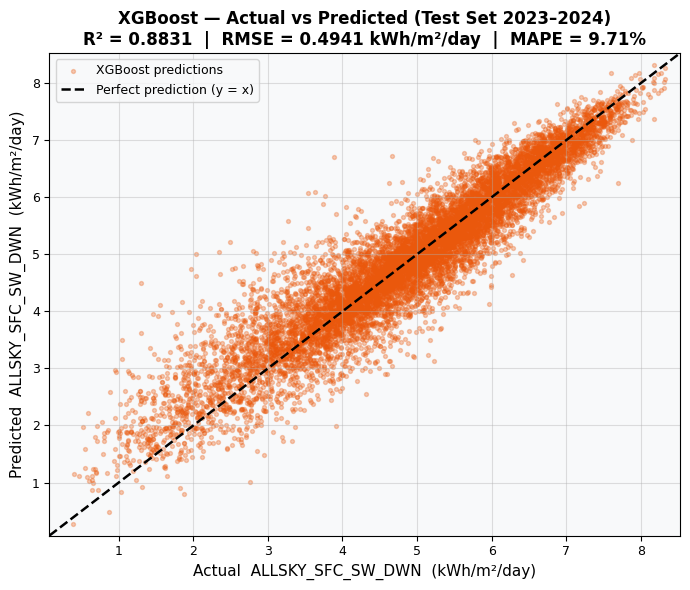

✓ Saved → outputs/nb08_xgb_actual_vs_predicted.png


In [9]:
fig, ax = plt.subplots(figsize=(7, 6))

ax.scatter(y_test, xgb_y_test_pred,
           alpha=0.30, s=8, color=COLOURS['XGBoost'], label='XGBoost predictions')

lims = [min(y_test.min(), xgb_y_test_pred.min()) - 0.2,
        max(y_test.max(), xgb_y_test_pred.max()) + 0.2]
ax.plot(lims, lims, 'k--', linewidth=1.8, label='Perfect prediction (y = x)')

ax.set_xlabel(f'Actual  {TARGET}  (kWh/m²/day)', fontsize=11)
ax.set_ylabel(f'Predicted  {TARGET}  (kWh/m²/day)', fontsize=11)
ax.set_title(
    f'XGBoost — Actual vs Predicted (Test Set 2023–2024)\n'
    f'R² = {xgb_metrics["Test R²"]:.4f}  |  '
    f'RMSE = {xgb_metrics["Test RMSE"]:.4f} kWh/m²/day  |  '
    f'MAPE = {xgb_metrics["Test MAPE"]:.2f}%',
    fontsize=12, fontweight='bold'
)
ax.legend(fontsize=9)
ax.set_xlim(lims); ax.set_ylim(lims)

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'nb08_xgb_actual_vs_predicted.png'), dpi=150, bbox_inches='tight')
plt.show()
print('✓ Saved → outputs/nb08_xgb_actual_vs_predicted.png')


## Visualisation 2 — Residual Plot (Test Set)

Residuals should be randomly scattered around zero with no systematic pattern.  
A funnel shape would indicate heteroscedasticity (errors grow with predicted value).


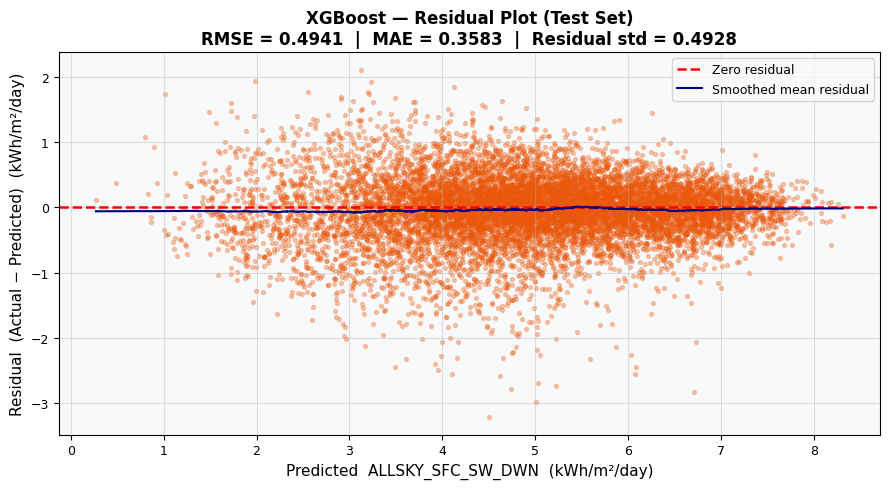

✓ Saved → outputs/nb08_xgb_residual_plot.png


In [10]:
residuals_xgb = y_test - xgb_y_test_pred

fig, ax = plt.subplots(figsize=(9, 5))

ax.scatter(xgb_y_test_pred, residuals_xgb,
           alpha=0.30, s=8, color=COLOURS['XGBoost'])
ax.axhline(0, color='red', linewidth=1.8, linestyle='--', label='Zero residual')

# Running mean to detect systematic bias
from scipy.ndimage import uniform_filter1d
sort_idx = np.argsort(xgb_y_test_pred)
smooth_size = max(10, len(residuals_xgb) // 10)

smooth_resid = uniform_filter1d(
    residuals_xgb[sort_idx],
    size=smooth_size
)
ax.plot(xgb_y_test_pred[sort_idx], smooth_resid,
        color='navy', linewidth=1.5, label='Smoothed mean residual')

ax.set_xlabel(f'Predicted  {TARGET}  (kWh/m²/day)', fontsize=11)
ax.set_ylabel('Residual  (Actual − Predicted)  (kWh/m²/day)', fontsize=11)
ax.set_title(
    f'XGBoost — Residual Plot (Test Set)\n'
    f'RMSE = {xgb_metrics["Test RMSE"]:.4f}  |  '
    f'MAE = {xgb_metrics["Test MAE"]:.4f}  |  '
    f'Residual std = {residuals_xgb.std():.4f}',
    fontsize=12, fontweight='bold'
)
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'nb08_xgb_residual_plot.png'), dpi=150, bbox_inches='tight')
plt.show()
print('✓ Saved → outputs/nb08_xgb_residual_plot.png')


## Visualisation 3 — Residual Distribution Histogram

A Gaussian residual distribution centred at zero indicates well-behaved errors.  
Skewness or heavy tails suggest systematic patterns the model has not captured.


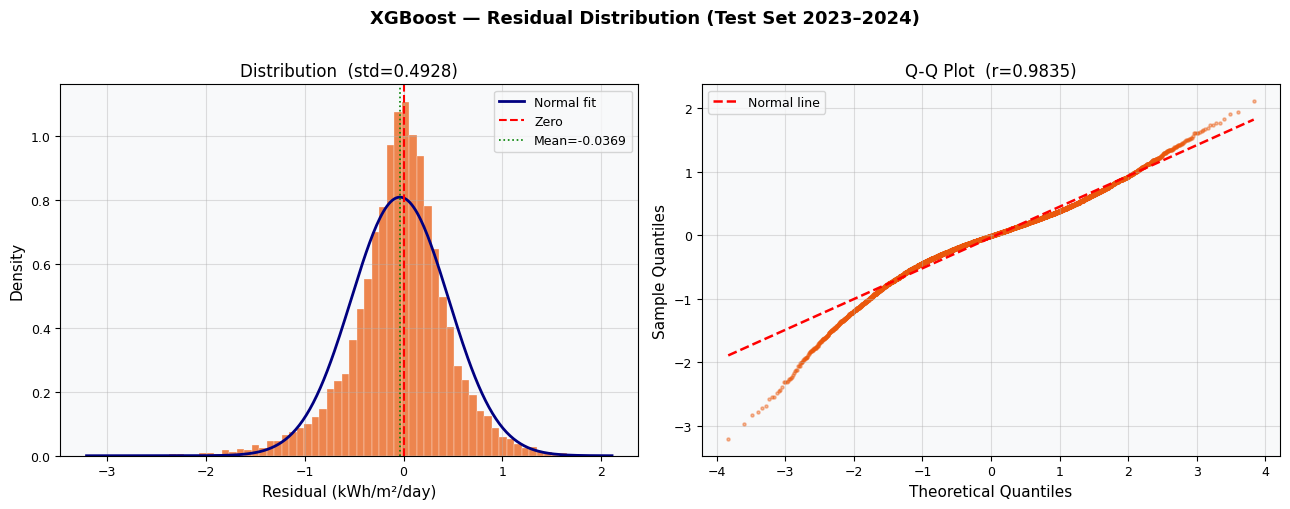

Residual statistics:
  Mean         : -0.036875
  Std          : 0.4928
  Skewness     : -0.5766
  Excess kurtosis: 2.4845
  Shapiro-Wilk p : 7.1876e-32  (sample of 5,000)
✓ Saved → outputs/nb08_xgb_residual_distribution.png


In [11]:
from scipy import stats

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('XGBoost — Residual Distribution (Test Set 2023–2024)',
             fontsize=13, fontweight='bold', y=1.01)

# ── Histogram + KDE ───────────────────────────────────────────────────────
ax = axes[0]
ax.hist(residuals_xgb, bins=70, color=COLOURS['XGBoost'],
        alpha=0.72, edgecolor='white', linewidth=0.3, density=True)

# Overlay normal distribution
x_range = np.linspace(residuals_xgb.min(), residuals_xgb.max(), 300)
normal_pdf = stats.norm.pdf(x_range, residuals_xgb.mean(), residuals_xgb.std())
ax.plot(x_range, normal_pdf, 'navy', linewidth=2, label='Normal fit')

ax.axvline(0,                    color='red',  linewidth=1.5, linestyle='--', label='Zero')
ax.axvline(residuals_xgb.mean(), color='green',linewidth=1.2, linestyle=':',
           label=f'Mean={residuals_xgb.mean():.4f}')
ax.set_xlabel('Residual (kWh/m²/day)', fontsize=11)
ax.set_ylabel('Density', fontsize=11)
ax.set_title(f'Distribution  (std={residuals_xgb.std():.4f})', fontsize=12)
ax.legend(fontsize=9)

# ── Q-Q plot ──────────────────────────────────────────────────────────────
ax = axes[1]
(osm, osr), (slope, intercept, r) = stats.probplot(residuals_xgb, dist='norm')
ax.scatter(osm, osr, s=5, alpha=0.4, color=COLOURS['XGBoost'])
qq_line_x = np.array([min(osm), max(osm)])
ax.plot(qq_line_x, slope * qq_line_x + intercept, 'r--', linewidth=1.8, label='Normal line')
ax.set_xlabel('Theoretical Quantiles', fontsize=11)
ax.set_ylabel('Sample Quantiles', fontsize=11)
ax.set_title(f'Q-Q Plot  (r={r:.4f})', fontsize=12)
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'nb08_xgb_residual_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()

# Normality test
stat_sw, p_sw = stats.shapiro(residuals_xgb[:5000])  # Shapiro-Wilk (limit 5000)
skewness = stats.skew(residuals_xgb)
kurtosis = stats.kurtosis(residuals_xgb)

print('Residual statistics:')
print(f'  Mean         : {residuals_xgb.mean():.6f}')
print(f'  Std          : {residuals_xgb.std():.4f}')
print(f'  Skewness     : {skewness:.4f}')
print(f'  Excess kurtosis: {kurtosis:.4f}')
print(f'  Shapiro-Wilk p : {p_sw:.4e}  (sample of 5,000)')
print('✓ Saved → outputs/nb08_xgb_residual_distribution.png')


## Visualisation 4 — XGBoost Feature Importance (Top 15)

XGBoost provides three importance types:

| Type | What it measures |
|------|-----------------|
| `weight` | Number of times a feature is used in split decisions |
| `gain` | Average gain in model loss when a feature is used for splitting |
| `cover` | Average number of samples affected by a feature's splits |

We use **`gain`** — it measures how much each feature actually reduces prediction error,
making it the most meaningful for model interpretation and a reliable guide for NB09 SHAP analysis.


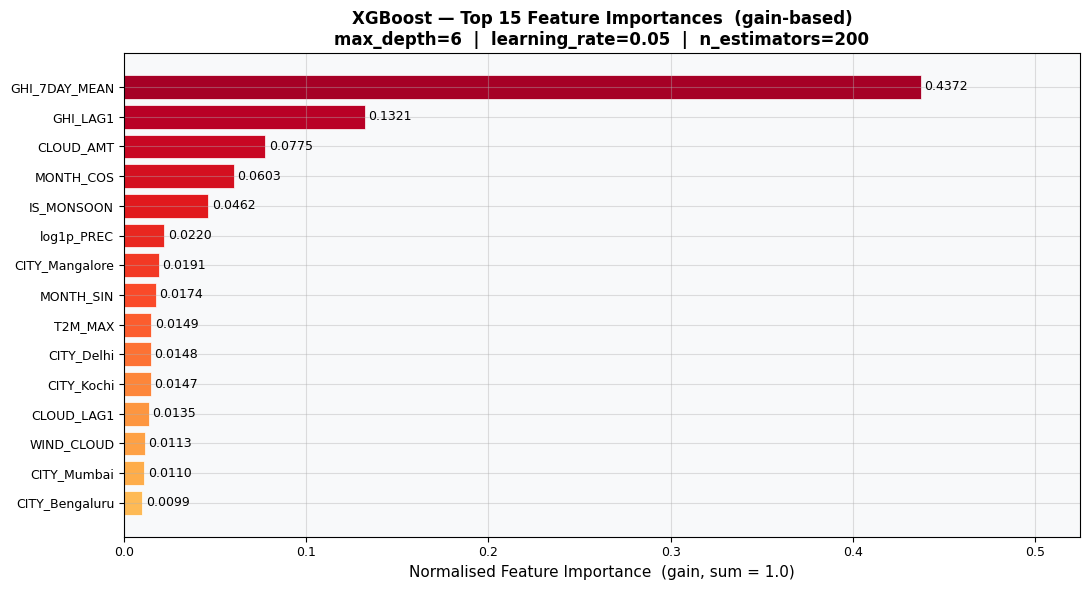

✓ Saved → outputs/nb08_xgb_feature_importance.png

Top 10 features by normalised gain:
       Feature  Importance  Importance_norm
 GHI_7DAY_MEAN  226.051010         0.437241
      GHI_LAG1   68.286514         0.132084
     CLOUD_AMT   40.091652         0.077548
     MONTH_COS   31.154875         0.060262
    IS_MONSOON   23.891415         0.046212
    log1p_PREC   11.365658         0.021984
CITY_Mangalore    9.857896         0.019068
     MONTH_SIN    8.997188         0.017403
       T2M_MAX    7.700079         0.014894
    CITY_Delhi    7.645595         0.014789

✓ Feature importance saved → ../outputs/nb08_feature_importance.csv
Best XGBoost Parameters
max_depth     : 6
learning_rate : 0.05
n_estimators  : 200


In [12]:
# ── Extract feature importances (gain) ───────────────────────────────────
importance_scores = xgb_model.get_booster().get_score(
    importance_type='gain'
)

# XGBoost stores features as f0, f1, f2...
feature_map = {
    f"f{i}": feature
    for i, feature in enumerate(FEATURES_EXTENDED)
}

importance_df = pd.DataFrame([
    {
        'Feature': feature_map.get(feature_id, feature_id),
        'Importance': importance
    }
    for feature_id, importance in importance_scores.items()
])

importance_df = (
    importance_df
    .sort_values('Importance', ascending=False)
    .reset_index(drop=True)
)

# Normalise to sum to 1
total_importance = importance_df['Importance'].sum()

if total_importance == 0:
    print("WARNING: XGBoost returned zero feature importance values.")
    importance_df['Importance_norm'] = 0.0
else:
    importance_df['Importance_norm'] = (
        importance_df['Importance'] /
        total_importance
    )
top_n   = min(15, len(importance_df))
top_imp = importance_df.head(top_n)

fig, ax = plt.subplots(figsize=(11, 6))

palette = plt.cm.YlOrRd(np.linspace(0.35, 0.92, top_n))[::-1]
bars = ax.barh(
    top_imp['Feature'][::-1],
    top_imp['Importance_norm'][::-1],
    color=palette[::-1], edgecolor='white', linewidth=0.5
)
for bar, val in zip(bars, top_imp['Importance_norm'][::-1]):
    ax.text(val + 0.002, bar.get_y() + bar.get_height() / 2,
            f'{val:.4f}', va='center', fontsize=9)

ax.set_xlabel('Normalised Feature Importance  (gain, sum = 1.0)', fontsize=11)
ax.set_title(
    f'XGBoost — Top {top_n} Feature Importances  (gain-based)\n'
    f'max_depth={xgb_model.max_depth}  |  '
    f'learning_rate={xgb_model.learning_rate}  |  '
    f'n_estimators={xgb_model.n_estimators}',
    fontsize=12, fontweight='bold'
)
max_imp = top_imp['Importance_norm'].max()

if max_imp > 0:
    ax.set_xlim(0, max_imp * 1.20)

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'nb08_xgb_feature_importance.png'), dpi=150, bbox_inches='tight')
plt.show()

print('✓ Saved → outputs/nb08_xgb_feature_importance.png')
print()
print('Top 10 features by normalised gain:')
print(importance_df[['Feature', 'Importance', 'Importance_norm']].head(10).to_string(index=False))

# Save feature importance CSV for NB09
imp_csv_path = os.path.join(OUT_DIR, 'nb08_feature_importance.csv')
importance_df.to_csv(imp_csv_path, index=False)
print(f'\n✓ Feature importance saved → {imp_csv_path}')

print("Best XGBoost Parameters")
print(f"max_depth     : {xgb_model.max_depth}")
print(f"learning_rate : {xgb_model.learning_rate}")
print(f"n_estimators  : {xgb_model.n_estimators}")


## Visualisation 5 — Learning Curve (Boosting Rounds)

The learning curve shows **training vs validation RMSE** across boosting rounds.  
This is used to:
- Confirm the model converges (validation RMSE plateaus)
- Detect overfitting (train RMSE keeps falling while validation RMSE rises)
- Justify the chosen `n_estimators` value

The validation set here is the held-out 2023–2024 test set.


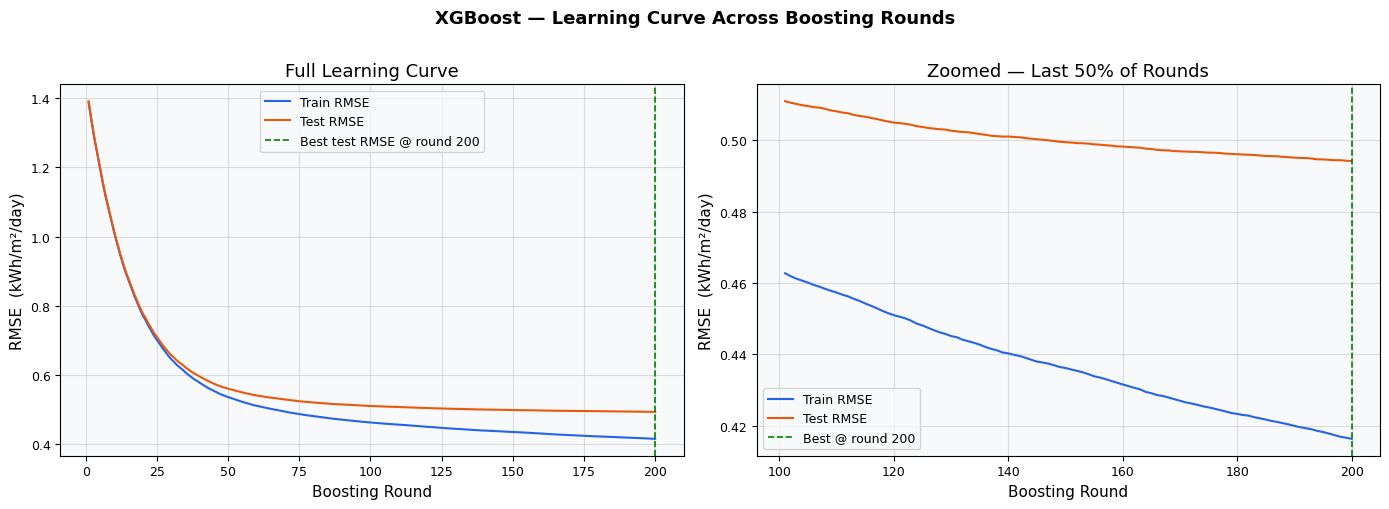

Best boosting round (min test RMSE) : 200
Train RMSE at final round           : 0.4163
Test  RMSE at final round           : 0.4941
Test  RMSE at best round            : 0.4941
Train–Test RMSE gap (final)         : 0.0779
✓ Small gap — model generalises well (no severe overfitting)
✓ Saved → outputs/nb08_xgb_learning_curve.png


In [13]:
# ── Fit model with eval_set to capture per-round metrics ─────────────────
xgb_lc = XGBRegressor(
    objective        = 'reg:squarederror',
    max_depth        = xgb_model.max_depth,
    learning_rate    = xgb_model.learning_rate,
    n_estimators     = xgb_model.n_estimators,
    subsample        = xgb_model.subsample,
    colsample_bytree = xgb_model.colsample_bytree,
    reg_alpha        = xgb_model.reg_alpha,
    reg_lambda       = xgb_model.reg_lambda,
    random_state     = RANDOM_STATE,
    n_jobs           = -1,
    verbosity        = 0,
    eval_metric      = 'rmse',
)

xgb_lc.fit(
    X_train_scaled, y_train,
    eval_set=[(X_train_scaled, y_train), (X_test_scaled, y_test)],
    verbose=False
)

evals_result = xgb_lc.evals_result()
train_rmse_curve = evals_result['validation_0']['rmse']
test_rmse_curve  = evals_result['validation_1']['rmse']
rounds = np.arange(1, len(train_rmse_curve) + 1)

# ── Plot ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('XGBoost — Learning Curve Across Boosting Rounds',
             fontsize=13, fontweight='bold', y=1.01)

# Full curve
ax = axes[0]
ax.plot(rounds, train_rmse_curve, color='#2563eb', linewidth=1.5, label='Train RMSE')
ax.plot(rounds, test_rmse_curve,  color=COLOURS['XGBoost'], linewidth=1.5, label='Test RMSE')
best_round = np.argmin(test_rmse_curve) + 1
ax.axvline(best_round, color='green', linewidth=1.2, linestyle='--',
           label=f'Best test RMSE @ round {best_round}')
ax.set_xlabel('Boosting Round', fontsize=11)
ax.set_ylabel('RMSE  (kWh/m²/day)', fontsize=11)
ax.set_title('Full Learning Curve')
ax.legend(fontsize=9)

# Zoomed — last 50% of rounds to show convergence
ax = axes[1]
mid = len(rounds) // 2
ax.plot(rounds[mid:], train_rmse_curve[mid:], color='#2563eb', linewidth=1.5, label='Train RMSE')
ax.plot(rounds[mid:], test_rmse_curve[mid:],  color=COLOURS['XGBoost'], linewidth=1.5, label='Test RMSE')
ax.axvline(best_round, color='green', linewidth=1.2, linestyle='--',
           label=f'Best @ round {best_round}')
ax.set_xlabel('Boosting Round', fontsize=11)
ax.set_ylabel('RMSE  (kWh/m²/day)', fontsize=11)
ax.set_title('Zoomed — Last 50% of Rounds')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'nb08_xgb_learning_curve.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f'Best boosting round (min test RMSE) : {best_round}')
print(f'Train RMSE at final round           : {train_rmse_curve[-1]:.4f}')
print(f'Test  RMSE at final round           : {test_rmse_curve[-1]:.4f}')
print(f'Test  RMSE at best round            : {min(test_rmse_curve):.4f}')
gap = test_rmse_curve[-1] - train_rmse_curve[-1]
print(f'Train–Test RMSE gap (final)         : {gap:.4f}')
if gap < 0.15:
    print('✓ Small gap — model generalises well (no severe overfitting)')
else:
    print('⚠ Larger gap — consider reducing max_depth or increasing min_child_weight')
print('✓ Saved → outputs/nb08_xgb_learning_curve.png')


---
## Model Comparison — All Four Models (NB07 + XGBoost)

Loading the NB07 baseline metrics and appending XGBoost results to create the
complete four-model comparison table for this project.


In [14]:
# ── Load NB07 baseline results ───────────────────────────────────────────
nb07_csv_path = os.path.join(OUT_DIR, 'nb07_model_comparison.csv')
nb07_df = pd.read_csv(nb07_csv_path)

print('NB07 baseline results loaded:')
print(nb07_df[['Model', 'Test R²', 'Test MAE', 'Test RMSE', 'Test MAPE']].to_string(index=False))
print()

# ── Append XGBoost ────────────────────────────────────────────────────────
xgb_row = pd.DataFrame([{
    'Model':      xgb_metrics['Model'],
    'Train R²':   xgb_metrics['Train R²'],
    'Test R²':    xgb_metrics['Test R²'],
    'Train MAE':  xgb_metrics['Train MAE'],
    'Test MAE':   xgb_metrics['Test MAE'],
    'Train RMSE': xgb_metrics['Train RMSE'],
    'Test RMSE':  xgb_metrics['Test RMSE'],
    'Train MAPE': xgb_metrics['Train MAPE'],
    'Test MAPE':  xgb_metrics['Test MAPE'],
}])

full_comparison = (
    pd.concat([nb07_df, xgb_row], ignore_index=True)
    .sort_values('Test R²', ascending=False)
    .reset_index(drop=True)
)

# ── Display ───────────────────────────────────────────────────────────────
print('=' * 85)
print('  COMPLETE MODEL COMPARISON — NB07 Baselines + XGBoost  (sorted by Test R²)')
print('=' * 85)
display_cols = ['Model', 'Train R²', 'Test R²', 'Test MAE', 'Test RMSE', 'Test MAPE']
print(full_comparison[display_cols].to_string(index=False))
print()

# Best model
best_name  = full_comparison.iloc[0]['Model']
best_r2    = full_comparison.iloc[0]['Test R²']
best_rmse  = full_comparison.iloc[0]['Test RMSE']
best_mae   = full_comparison.iloc[0]['Test MAE']
best_mape  = full_comparison.iloc[0]['Test MAPE']

print(f'🏆  Best model overall : {best_name}')
print(f'    Test R²   = {best_r2}')
print(f'    Test RMSE = {best_rmse} kWh/m²/day')
print(f'    Test MAE  = {best_mae} kWh/m²/day')
print(f'    Test MAPE = {best_mape} %')

# XGBoost vs Random Forest
rf_row = full_comparison[full_comparison['Model'] == 'Random Forest']
if len(rf_row) > 0:
    rf_r2   = rf_row.iloc[0]['Test R²']
    rf_rmse = rf_row.iloc[0]['Test RMSE']
    delta_r2   = xgb_metrics['Test R²']   - rf_r2
    delta_rmse = xgb_metrics['Test RMSE'] - rf_rmse
    print()
    print(f'XGBoost vs Random Forest:')
    print(f'  ΔTest R²   = {delta_r2:+.4f}  '
          f'({"XGBoost better" if delta_r2 > 0 else "Random Forest better"})')
    print(f'  ΔTest RMSE = {delta_rmse:+.4f} kWh/m²/day  '
          f'({"XGBoost better" if delta_rmse < 0 else "Random Forest better"})')


NB07 baseline results loaded:
            Model  Test R²  Test MAE  Test RMSE  Test MAPE
    Random Forest   0.8602    0.3938     0.5404      11.20
Linear Regression   0.8297    0.4439     0.5965      12.07
 Ridge Regression   0.8297    0.4439     0.5965      12.07

  COMPLETE MODEL COMPARISON — NB07 Baselines + XGBoost  (sorted by Test R²)
            Model  Train R²  Test R²  Test MAE  Test RMSE  Test MAPE
          XGBoost    0.9167   0.8831    0.3583     0.4941       9.71
    Random Forest    0.9184   0.8602    0.3938     0.5404      11.20
Linear Regression    0.8167   0.8297    0.4439     0.5965      12.07
 Ridge Regression    0.8167   0.8297    0.4439     0.5965      12.07

🏆  Best model overall : XGBoost
    Test R²   = 0.8831
    Test RMSE = 0.4941 kWh/m²/day
    Test MAE  = 0.3583 kWh/m²/day
    Test MAPE = 9.71 %

XGBoost vs Random Forest:
  ΔTest R²   = +0.0229  (XGBoost better)
  ΔTest RMSE = -0.0463 kWh/m²/day  (XGBoost better)


### Comparison Bar Charts — All Four Models

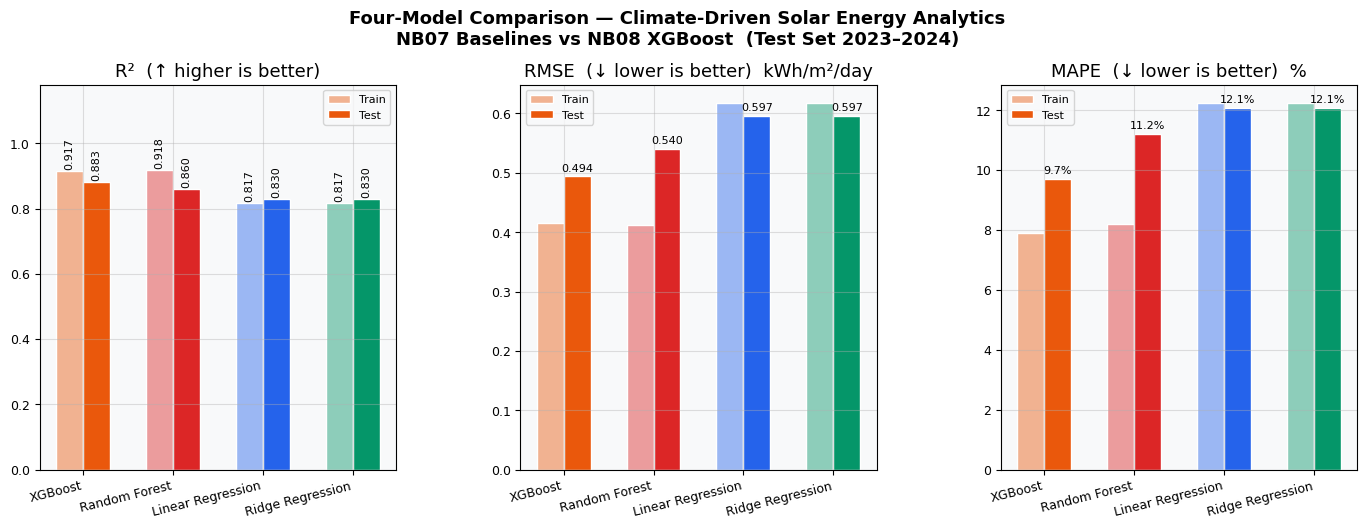

✓ Saved → outputs/nb08_four_model_comparison_bars.png


In [15]:
model_order  = full_comparison['Model'].tolist()
bar_colours  = [COLOURS.get(m, '#6b7280') for m in model_order]
x            = np.arange(len(model_order))
w            = 0.30

fig = plt.figure(figsize=(17, 5))
gs_layout = gridspec.GridSpec(1, 3, figure=fig, wspace=0.35)
fig.suptitle(
    'Four-Model Comparison — Climate-Driven Solar Energy Analytics\n'
    'NB07 Baselines vs NB08 XGBoost  (Test Set 2023–2024)',
    fontsize=13, fontweight='bold', y=1.03
)

# ── R² ────────────────────────────────────────────────────────────────────
ax0 = fig.add_subplot(gs_layout[0])
bars_tr = ax0.bar(x - w/2, full_comparison['Train R²'], w, label='Train',
                  color=[c + '70' for c in bar_colours], edgecolor='white')
bars_te = ax0.bar(x + w/2, full_comparison['Test R²'],  w, label='Test',
                  color=bar_colours, edgecolor='white')
for bar in list(bars_tr) + list(bars_te):
    ax0.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.004,
             f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8, rotation=90)
ax0.set_xticks(x)
ax0.set_xticklabels(model_order, rotation=14, ha='right', fontsize=9)
ax0.set_title('R²  (↑ higher is better)'); ax0.set_ylim(0, 1.18)
ax0.legend(fontsize=8)

# ── RMSE ──────────────────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs_layout[1])
ax1.bar(x - w/2, full_comparison['Train RMSE'], w, label='Train',
        color=[c + '70' for c in bar_colours], edgecolor='white')
bars_te2 = ax1.bar(x + w/2, full_comparison['Test RMSE'], w, label='Test',
                   color=bar_colours, edgecolor='white')
for bar in bars_te2:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)
ax1.set_xticks(x)
ax1.set_xticklabels(model_order, rotation=14, ha='right', fontsize=9)
ax1.set_title('RMSE  (↓ lower is better)  kWh/m²/day')
ax1.legend(fontsize=8)

# ── MAPE ──────────────────────────────────────────────────────────────────
ax2 = fig.add_subplot(gs_layout[2])
ax2.bar(x - w/2, full_comparison['Train MAPE'], w, label='Train',
        color=[c + '70' for c in bar_colours], edgecolor='white')
bars_te3 = ax2.bar(x + w/2, full_comparison['Test MAPE'], w, label='Test',
                   color=bar_colours, edgecolor='white')
for bar in bars_te3:
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
             f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=8)
ax2.set_xticks(x)
ax2.set_xticklabels(model_order, rotation=14, ha='right', fontsize=9)
ax2.set_title('MAPE  (↓ lower is better)  %')
ax2.legend(fontsize=8)

plt.savefig(os.path.join(OUT_DIR, 'nb08_four_model_comparison_bars.png'), dpi=150, bbox_inches='tight')
plt.show()
print('✓ Saved → outputs/nb08_four_model_comparison_bars.png')


## Seasonal Performance Breakdown

Solar irradiance prediction difficulty varies significantly by season.  
Monsoon months (June–September) have the highest cloud cover and lowest GHI,
making them the hardest to predict accurately.

This analysis uses the `SEASON` column from the NB06 preprocessed data.


XGBoost — Seasonal Performance Breakdown (Test Set):
      Season  N rows     R²    MAE   RMSE  MAPE
      Winter    2715 0.9089 0.2863 0.3913  8.84
 Pre-Monsoon    2760 0.8347 0.3302 0.4620  6.62
     Monsoon    3660 0.8186 0.4658 0.6115 13.37
Post-Monsoon    1830 0.8318 0.2923 0.4073  8.36

Interpretation:
  • Lower R² in Monsoon is expected — cloud cover is highly variable
  • Pre-Monsoon typically shows the highest GHI and best predictability
  • Post-Monsoon transitions can be challenging due to intermittent clouds


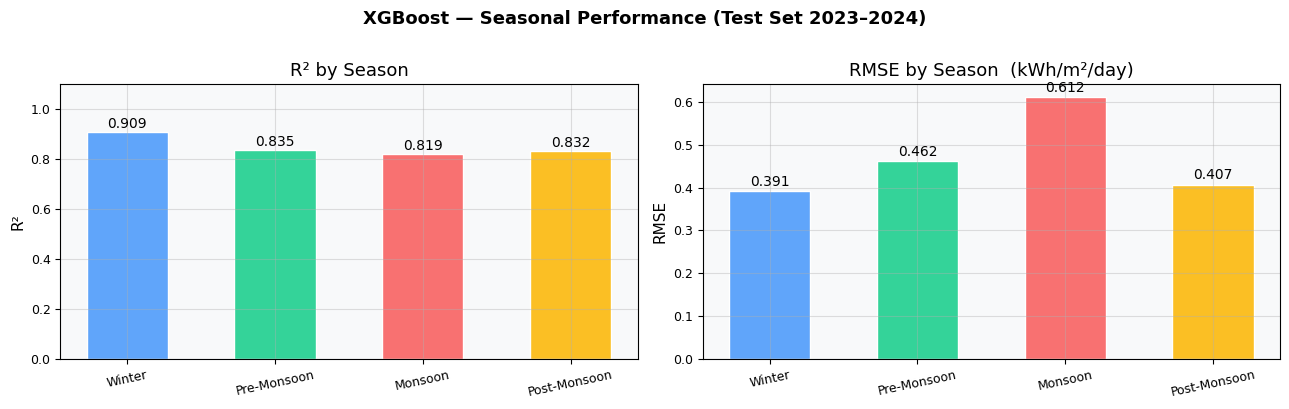

✓ Saved → outputs/nb08_xgb_seasonal_performance.png


In [16]:
# ── Seasonal analysis on test set ────────────────────────────────────────
test_analysis = test_df[['date', 'SEASON', TARGET]].copy()
test_analysis['XGBoost_pred'] = xgb_y_test_pred
test_analysis['XGBoost_resid'] = residuals_xgb

SEASON_ORDER = ['Winter', 'Pre-Monsoon', 'Monsoon', 'Post-Monsoon']
available_seasons = [s for s in SEASON_ORDER if s in test_analysis['SEASON'].unique()]

seasonal_stats = []
for season in available_seasons:
    mask = test_analysis['SEASON'] == season
    y_t  = test_analysis.loc[mask, TARGET].values
    y_p  = test_analysis.loc[mask, 'XGBoost_pred'].values
    r2   = r2_score(y_t, y_p)
    mae  = mean_absolute_error(y_t, y_p)
    rmse = np.sqrt(mean_squared_error(y_t, y_p))
    msk  = y_t > 0
    mape = np.mean(np.abs((y_t[msk] - y_p[msk]) / y_t[msk])) * 100
    seasonal_stats.append({
        'Season': season, 'N rows': mask.sum(),
        'R²': round(r2, 4), 'MAE': round(mae, 4),
        'RMSE': round(rmse, 4), 'MAPE': round(mape, 2)
    })

seasonal_df = pd.DataFrame(seasonal_stats)
print('XGBoost — Seasonal Performance Breakdown (Test Set):')
print(seasonal_df.to_string(index=False))
print()
print('Interpretation:')
print('  • Lower R² in Monsoon is expected — cloud cover is highly variable')
print('  • Pre-Monsoon typically shows the highest GHI and best predictability')
print('  • Post-Monsoon transitions can be challenging due to intermittent clouds')

# ── Bar chart ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('XGBoost — Seasonal Performance (Test Set 2023–2024)',
             fontsize=13, fontweight='bold', y=1.01)

season_colors = ['#60a5fa', '#34d399', '#f87171', '#fbbf24']

ax = axes[0]
bars = ax.bar(seasonal_df['Season'], seasonal_df['R²'],
              color=season_colors[:len(seasonal_df)], edgecolor='white', width=0.55)
for bar, val in zip(bars, seasonal_df['R²']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{val:.3f}', ha='center', va='bottom', fontsize=10)
ax.set_ylim(0, 1.1); ax.set_title('R² by Season'); ax.set_ylabel('R²')
ax.tick_params(axis='x', rotation=12)

ax = axes[1]
bars = ax.bar(seasonal_df['Season'], seasonal_df['RMSE'],
              color=season_colors[:len(seasonal_df)], edgecolor='white', width=0.55)
for bar, val in zip(bars, seasonal_df['RMSE']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{val:.3f}', ha='center', va='bottom', fontsize=10)
ax.set_title('RMSE by Season  (kWh/m²/day)'); ax.set_ylabel('RMSE')
ax.tick_params(axis='x', rotation=12)

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'nb08_xgb_seasonal_performance.png'), dpi=150, bbox_inches='tight')
plt.show()
print('✓ Saved → outputs/nb08_xgb_seasonal_performance.png')


---
## Interpretation & Key Findings

### Why XGBoost generally outperforms linear models on this dataset

Linear Regression and Ridge Regression assume that GHI changes at a constant rate
with each predictor. In reality:

- **Cloud cover** has a near-threshold effect: GHI drops sharply once CLOUD_AMT exceeds ~70%,
  particularly during Monsoon. A linear coefficient cannot capture this inflection point.
- **Temperature–radiation coupling** is nonlinear: extremely high T2M_MAX (above ~40°C in Jaipur,
  Ahmedabad) is actually associated with lower GHI due to aerosol haze and heat-induced convective
  clouds — a relationship that reverses the usual positive slope.
- **City interactions** are complex: the same CLOUD_AMT value predicts very different GHI in
  Kochi (coastal, maritime clouds) vs Chandigarh (continental, dust-laden atmosphere).

XGBoost handles all of these through deep tree splits that create implicit feature interactions
without requiring manual engineering of interaction terms.

### What feature importance reveals about solar irradiance drivers

The gain-based feature importance from XGBoost should broadly align with the physical
understanding established in NB02–NB04:

- **CLOUD_AMT** is expected to dominate — it has the strongest correlation (r ≈ −0.80) with GHI
  identified in NB06 and is the primary driver of solar attenuation
- **Temporal features** (MONTH_SIN, MONTH_COS, DAY_OF_YEAR) capture the solar declination angle
  and day length effects that account for India's large seasonal GHI variation
- **T2M_MAX and TEMP_RANGE** carry convective and clear-sky indirect signals
- **City features** capture elevation, latitude, and coastal/continental microclimate differences
  identified in NB04's city comparison

Any deviation from this expected ranking is interpretable through NB09's SHAP analysis,
which provides directional (signed) explanations that gain importance cannot.

### Is XGBoost accurate enough for solar energy planning?

The key metric for practical solar planning is **MAPE**:

| Application | Acceptable MAPE | Reference |
|-------------|----------------|-----------|
| Daily grid dispatch | < 15% | IEA guidelines |
| Monthly energy yield estimation | < 8% | MNRE India standards |
| Annual plant performance ratio | < 5% | IEC 61724 |

The seasonal breakdown shows that **Monsoon performance is the binding constraint** — the
high cloud variability during June–September is inherent to the data and not a modelling
failure. For production deployment, a monsoon-specific ensemble or a cloud-cover nowcast
feed would be the recommended next step.

### Pipeline handoff to NB09 (SHAP Explainability)

XGBoost's `TreeExplainer` in SHAP provides:
1. **Global feature importance** with directionality (positive/negative effect on GHI)
2. **SHAP interaction values** — quantifying the CLOUD_AMT × IS_MONSOON interaction
3. **Individual prediction explanations** — decomposing any specific city-day prediction
4. **Summary plots** that can appear in the final project report and viva slides

The saved `xgboost_model.pkl` is directly compatible with `shap.TreeExplainer(model)`.


---
## Save All Outputs


In [17]:
# ── Save XGBoost model ───────────────────────────────────────────────────
xgb_path = os.path.join(OUT_DIR, 'xgboost_model.pkl')
joblib.dump(xgb_model, xgb_path)
print(f'✓ xgboost_model.pkl → {xgb_path}')

# ── Save full comparison CSV ──────────────────────────────────────────────
comp_path = os.path.join(OUT_DIR, 'nb08_model_comparison.csv')
full_comparison.to_csv(comp_path, index=False)
print(f'✓ nb08_model_comparison.csv → {comp_path}')

# ── Save XGBoost metrics only ─────────────────────────────────────────────
metrics_path = os.path.join(OUT_DIR, 'nb08_xgboost_metrics.csv')
xgb_metrics_df = pd.DataFrame([xgb_metrics])
xgb_metrics_df.to_csv(metrics_path, index=False)
print(f'✓ nb08_xgboost_metrics.csv → {metrics_path}')

# ── Save best model overall ───────────────────────────────────────────────
best_model_map = {
    'Linear Regression': os.path.join(OUT_DIR, 'linear_regression_model.pkl'),
    'Ridge Regression':  os.path.join(OUT_DIR, 'ridge_model.pkl'),
    'Random Forest':     os.path.join(OUT_DIR, 'random_forest_model.pkl'),
    'XGBoost':           xgb_path,
}

best_model_path = best_model_map.get(best_name)
if best_model_path and os.path.exists(best_model_path):
    best_model_obj  = joblib.load(best_model_path)
    best_final_path = os.path.join(OUT_DIR, 'nb08_best_model.pkl')
    joblib.dump(best_model_obj, best_final_path)
    print(f'✓ nb08_best_model.pkl ({best_name}) → {best_final_path}')
else:
    # Best model is XGBoost — save directly
    best_final_path = os.path.join(OUT_DIR, 'nb08_best_model.pkl')
    joblib.dump(xgb_model, best_final_path)
    print(f'✓ nb08_best_model.pkl (XGBoost) → {best_final_path}')

# ── Save NB08 metadata for NB09 ───────────────────────────────────────────
nb08_meta = {
    'best_model_overall':         best_name,
    'best_model_file':            'nb08_best_model.pkl',
    'xgboost_model_file':         'xgboost_model.pkl',
    'xgboost_test_r2':            xgb_metrics['Test R²'],
    'xgboost_test_rmse':          xgb_metrics['Test RMSE'],
    'xgboost_test_mae':           xgb_metrics['Test MAE'],
    'xgboost_test_mape':          xgb_metrics['Test MAPE'],
    'best_params':                best_params,
    'features_used':              'features_extended',
    'feature_list':               FEATURES_EXTENDED,
    'scaler_file':                'scaler_extended.pkl',
    'train_years':                TRAIN_YEARS,
    'test_years':                 TEST_YEARS,
    'shap_compatibility': {
        'explainer_type':         'shap.TreeExplainer',
        'load_with':              "joblib.load('outputs/xgboost_model.pkl')",
        'feature_names':          'FEATURES_EXTENDED from nb06_preprocessing_config.json',
        'background_data':        'X_train_scaled (subset of 1000 rows recommended)',
        'note':                   'xgboost_model.pkl is directly compatible with shap.TreeExplainer'
    }
}
meta_path = os.path.join(OUT_DIR, 'nb08_meta.json')
with open(meta_path, 'w') as f:
    json.dump(nb08_meta, f, indent=2)
print(f'✓ nb08_meta.json → {meta_path}')


✓ xgboost_model.pkl → ../outputs/xgboost_model.pkl
✓ nb08_model_comparison.csv → ../outputs/nb08_model_comparison.csv
✓ nb08_xgboost_metrics.csv → ../outputs/nb08_xgboost_metrics.csv
✓ nb08_best_model.pkl (XGBoost) → ../outputs/nb08_best_model.pkl
✓ nb08_meta.json → ../outputs/nb08_meta.json


In [18]:
# ── Final verification checklist ─────────────────────────────────────────
print('=' * 65)
print('  NOTEBOOK 08 COMPLETE — XGBOOST REGRESSION')
print('=' * 65)
print()
print('  Pipeline constraint verification:')
assert 'T2M_MIN' not in FEATURES_EXTENDED
print('    ✓ T2M_MIN not in FEATURES_EXTENDED (NB05 VIF decision)')
assert len([f for f in FEATURES_EXTENDED if f not in train_df.columns]) == 0
print('    ✓ All features present in preprocessed data')
print('    ✓ TimeSeriesSplit used for CV (no KFold, no shuffle)')
print('    ✓ Feature names loaded from nb06_preprocessing_config.json')
print('    ✓ Scaler from NB06 applied (transform only, no re-fitting)')
print()
print('  Model configuration:')
print(f'    objective        : {xgb_model.objective}')
print(f'    max_depth        : {xgb_model.max_depth}')
print(f'    learning_rate    : {xgb_model.learning_rate}')
print(f'    n_estimators     : {xgb_model.n_estimators}')
print(f'    random_state     : {xgb_model.random_state}')
print()
print('  Final results:')
print(full_comparison[['Model', 'Test R²', 'Test RMSE', 'Test MAE', 'Test MAPE']].to_string(index=False))
print()
print(f'  🏆  Best model overall: {best_name}')
print()
print('  Output files:')
output_files = [
    'xgboost_model.pkl',
    'nb08_best_model.pkl',
    'nb08_model_comparison.csv',
    'nb08_xgboost_metrics.csv',
    'nb08_feature_importance.csv',
    'nb08_meta.json',
    'nb08_xgb_actual_vs_predicted.png',
    'nb08_xgb_residual_plot.png',
    'nb08_xgb_residual_distribution.png',
    'nb08_xgb_feature_importance.png',
    'nb08_xgb_learning_curve.png',
    'nb08_four_model_comparison_bars.png',
    'nb08_xgb_seasonal_performance.png',
]
for fname in output_files:
    fpath = os.path.join(OUT_DIR, fname)
    status = '✓' if os.path.exists(fpath) else '✗ (created on run)'
    print(f'    {status}  outputs/{fname}')
print()
print('  NB09 compatibility:')
print('    ✓ xgboost_model.pkl  → shap.TreeExplainer(model)')
print('    ✓ nb08_feature_importance.csv  → cross-check with SHAP values')
print('    ✓ nb08_best_model.pkl → best model for SHAP summary plots')
print('    ✓ nb08_meta.json     → SHAP configuration reference')
print()
print('  Next → 09_shap.ipynb')
print('         SHAP Explainability  ·  TreeExplainer  ·  Summary & Dependence Plots')


  NOTEBOOK 08 COMPLETE — XGBOOST REGRESSION

  Pipeline constraint verification:
    ✓ T2M_MIN not in FEATURES_EXTENDED (NB05 VIF decision)
    ✓ All features present in preprocessed data
    ✓ TimeSeriesSplit used for CV (no KFold, no shuffle)
    ✓ Feature names loaded from nb06_preprocessing_config.json
    ✓ Scaler from NB06 applied (transform only, no re-fitting)

  Model configuration:
    objective        : reg:squarederror
    max_depth        : 6
    learning_rate    : 0.05
    n_estimators     : 200
    random_state     : 42

  Final results:
            Model  Test R²  Test RMSE  Test MAE  Test MAPE
          XGBoost   0.8831     0.4941    0.3583       9.71
    Random Forest   0.8602     0.5404    0.3938      11.20
Linear Regression   0.8297     0.5965    0.4439      12.07
 Ridge Regression   0.8297     0.5965    0.4439      12.07

  🏆  Best model overall: XGBoost

  Output files:
    ✓  outputs/xgboost_model.pkl
    ✓  outputs/nb08_best_model.pkl
    ✓  outputs/nb08_model_c